# L1 · Notebook 04 — UAV 3D 网格：MDP 的"维度爆炸"演示

**对应 PPT**：`L1-basic.tex` § 应用扩展 / UAV 巡航示例（如有）

**对应教材**：`miclDRL/chapters/part2-ch01-basic-concepts.tex` § 应用案例

## 教学目标

1. 把同一套 MDP 五元组 $\langle\mathcal{S},\mathcal{A},P,r,\gamma\rangle$ 装到一个**有物理含义**的真实任务上（无人机巡航着陆）
2. 直观感受**维度爆炸**：$|\mathcal{S}|$ 从 GridWorld 5×5 的 25 跳到 **8 × 8 × 4 × 16 = 4096**（×164）
3. 验证：状态空间放大 100× 之后，**表格方法仍可行**（为 L4 的 VI 演示铺垫）

> ⚠️ 这是 GridWorld 的**扩展练习**，不是替换。L2/L3 仍用 5×5 网格做 Bellman 推导。


## 1. 准备：导入 UAVGrid3D 共享环境

环境来自 `code/shared/uav_grid.py`，**接口与 `GridWorld` 完全对齐**——同样的 `step / all_states /
transition_matrix / value_iteration`，L4-L7 的算法代码几乎零改动就能复用。

<table>
<colgroup>
  <col style="width: 12%">
  <col style="width: 38%">
  <col style="width: 25%">
  <col style="width: 25%">
</colgroup>
<thead>
<tr><th style="text-align:center">MDP 元素</th><th>UAVGrid3D 实现</th><th>规模</th><th>GridWorld 5×5 对照</th></tr>
</thead>
<tbody>
<tr><td style="text-align:center">$\mathcal{S}$</td><td>$(\text{row},\text{col},\text{alt},\text{battery})$</td><td>$\|\mathcal{S}\|=4096$</td><td>$(row,col)$，25</td></tr>
<tr><td style="text-align:center">$\mathcal{A}$</td><td><code>[north, south, west, east, hover, ascend, descend]</code></td><td>7 个</td><td><code>[up,down,left,right,stay]</code>，5 个</td></tr>
<tr><td style="text-align:center">$P(s'\mid s,a)$</td><td><code>env.step(s,a)</code>，确定性</td><td>—</td><td>同上</td></tr>
<tr><td style="text-align:center">$r(s,a)$</td><td>$r_\text{target}{=}{+}1$, $r_\text{forbidden}{=}{-}1$ (撞楼), $r_\text{boundary}{=}{-}1$ (出界), $r_\text{crash}{=}{-}1$ (耗尽), $r_\text{step}{=}0$</td><td>5 取值</td><td>4 取值，无电量</td></tr>
<tr><td style="text-align:center">$\gamma$</td><td><code>env.cfg.gamma = 0.9</code></td><td>—</td><td>同</td></tr>
</tbody>
</table>

**电量动力学**（每步从 battery 中扣）：

<table>
<colgroup>
  <col style="width: 25%">
  <col style="width: 35%">
  <col style="width: 40%">
</colgroup>
<thead>
<tr><th>动作</th><th>平面 / 高度位移</th><th>电量代价</th></tr>
</thead>
<tbody>
<tr><td><code>north / south / west / east</code></td><td>横向一格</td><td>$-1$</td></tr>
<tr><td><code>hover</code></td><td>不动</td><td>$0$</td></tr>
<tr><td><code>ascend</code></td><td>$\text{alt}{+}1$</td><td>$-2$（爬升费电）</td></tr>
<tr><td><code>descend</code></td><td>$\text{alt}{-}1$</td><td>$0$（俯冲免费）</td></tr>
</tbody>
</table>

楼宇用 `building_height[(row,col)] = h` 描述：$\text{alt}<h$ 全部禁飞，$\text{alt}\ge h$ 可以**越顶飞过**——这是高度维度真正带来的新自由度。


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from shared.uav_grid import (
    UAVGrid3D, UAVConfig, ACTIONS_3D,
    rollout, discounted_return, random_policy, building_mask,
)
from shared.plotting import setup_chinese_font
setup_chinese_font()

env = UAVGrid3D()
cfg = env.cfg
print(f'|S| = {env.n_states}   |A| = {env.n_actions}   γ = {cfg.gamma}')
print(f'grid = {cfg.n_rows}×{cfg.n_cols},  alts = {cfg.n_alts},  battery levels = {cfg.n_battery}')
print(f'target = {cfg.target}   start = {cfg.start}')
print(f'\n对比 GridWorld(5×5)：|S| 从 25 → {env.n_states} (×{env.n_states//25})')


|S| = 4096   |A| = 7   γ = 0.9
grid = 8×8,  alts = 4,  battery levels = 16
target = (6, 6, 0)   start = (0, 0, 3, 15)

对比 GridWorld(5×5)：|S| 从 25 → 4096 (×163)


## 2. 可视化：4 个高度层

楼宇 (B) 在不同高度的禁飞范围不一样——`alt=0` 时全部楼宇都挡路，`alt=3` 时只有最高楼 (3,3) 挡路。**这正是高度维度的教学意义**。


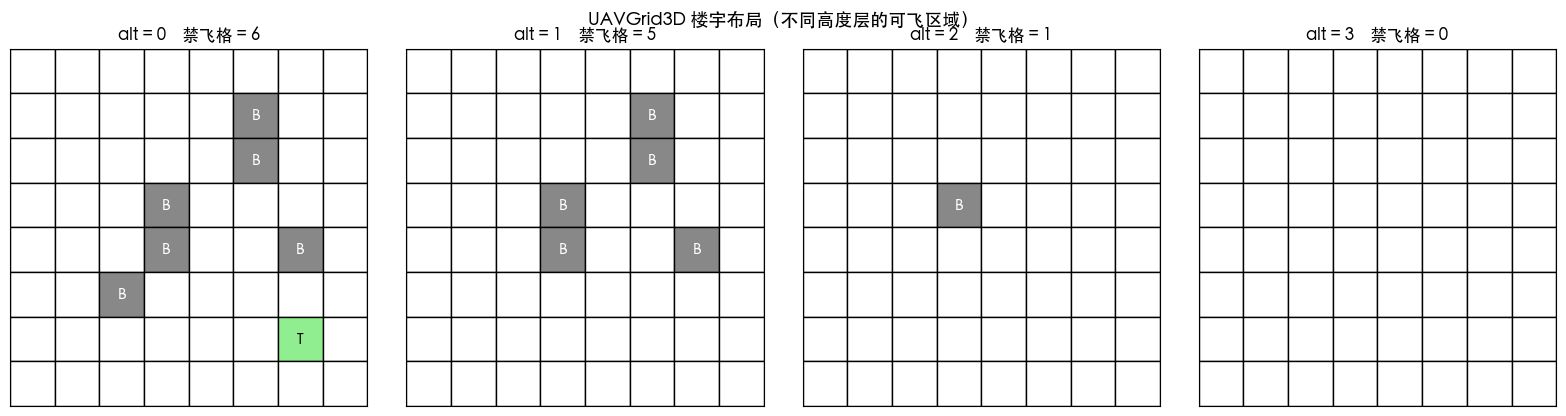

In [2]:
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, cfg.n_alts, figsize=(16, 4.2))
for alt in range(cfg.n_alts):
    ax = axes[alt]
    mask = building_mask(env, alt)
    for r in range(cfg.n_rows):
        for c in range(cfg.n_cols):
            y = cfg.n_rows - 1 - r
            if (r, c, alt) == cfg.target:
                color = '#90EE90'; label = 'T'
            elif mask[r, c]:
                color = '#888'; label = 'B'
            else:
                color = 'white'; label = ''
            ax.add_patch(Rectangle((c, y), 1, 1, facecolor=color, edgecolor='black'))
            if label:
                ax.text(c + 0.5, y + 0.5, label, ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if label == 'B' else 'black')
    n_block = int(mask.sum())
    ax.set_xlim(0, cfg.n_cols); ax.set_ylim(0, cfg.n_rows)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'alt = {alt}    禁飞格 = {n_block}')
fig.suptitle('UAVGrid3D 楼宇布局（不同高度层的可飞区域）', fontsize=13)
plt.tight_layout()
plt.savefig('figures/uav_layout.png', dpi=120, bbox_inches='tight')
plt.show()


**观察**：随高度上升，可飞格变多。无人机的合理策略——"先升高 → 直线穿越 → 末端俯冲着陆"——天然来源于这个结构。

## 3. 单步动力学：`step(s, a)` 的物理含义

从默认起点 `(0,0, alt=3, battery=15)` 演示每个动作。


In [3]:
s = cfg.start
print(f'初始 s = (row={s[0]}, col={s[1]}, alt={s[2]}, battery={s[3]})\n')
print(f"{'动作':<10}{'下一状态':<30}{'reward':<10}{'done'}")
print('-' * 60)
for a in ACTIONS_3D:
    sn, r, d = env.step(s, a)
    print(f'{a:<10}{str(sn):<30}{r:+.1f}      {d}')

print('\n再演示"撞楼"：从 (3,2,0,5) 试图 east → (3,3,0) 是楼，按 r_forbidden 反弹')
sn, r, d = env.step((3, 2, 0, 5), 'east')
print(f'  step((3,2,0,5), east) -> {sn}, r={r:+.1f}')

print('\n再演示"越顶飞过"：从 (3,2,3,5) east → (3,3,3) 因为楼高=3，alt=3 可通过')
sn, r, d = env.step((3, 2, 3, 5), 'east')
print(f'  step((3,2,3,5), east) -> {sn}, r={r:+.1f}')


初始 s = (row=0, col=0, alt=3, battery=15)

动作        下一状态                          reward    done
------------------------------------------------------------
north     (0, 0, 3, 14)                 -1.0      False
south     (1, 0, 3, 14)                 +0.0      False
west      (0, 0, 3, 14)                 -1.0      False
east      (0, 1, 3, 14)                 +0.0      False
hover     (0, 0, 3, 15)                 +0.0      False
ascend    (0, 0, 3, 13)                 -1.0      False
descend   (0, 0, 2, 15)                 +0.0      False

再演示"撞楼"：从 (3,2,0,5) 试图 east → (3,3,0) 是楼，按 r_forbidden 反弹
  step((3,2,0,5), east) -> (3, 2, 0, 4), r=-1.0

再演示"越顶飞过"：从 (3,2,3,5) east → (3,3,3) 因为楼高=3，alt=3 可通过
  step((3,2,3,5), east) -> (3, 3, 3, 4), r=+0.0


**观察**：
- `ascend` 一次扣 2 格电（费力上升），`descend` 0 电（势能转换），`hover` 0 电但白白浪费时间
- 撞楼时 agent 不前进、扣电 + r=-1（"撞了就疼，电还白扣了"）
- 高度 alt=3 时大部分楼可以越顶——给了 RL 一个非平凡的最优策略选择

## 4. 轨迹采样与折扣回报

用 VI 算最优策略，从起点 rollout 看一条**成功着陆**轨迹。


In [4]:
import time

t0 = time.time()
V, pi, residuals = env.value_iteration(tol=1e-9, max_iter=2000)
dt = time.time() - t0
print(f'VI 收敛于 {len(residuals)} 轮  耗时 {dt*1000:.1f} ms')
print(f'残差末项 ‖Δ‖∞ = {residuals[-1]:.2e}\n')

traj = rollout(env, pi, max_steps=80)
G = discounted_return(traj, cfg.gamma)
print(f'最优策略轨迹长度：{len(traj)} 步')
print(f'折扣回报 G_0 = {G:+.4f}  (理论值 γ^{len(traj)-1} = {cfg.gamma**(len(traj)-1):.4f})\n')

print(f"{'t':>3}  {'(row,col,alt,bat)':<20}  {'action':<8}  {'r':>5}  {'done'}")
for t, (s, a, r, sn) in enumerate(traj):
    print(f'{t:>3}  {str(s):<20}  {a:<8}  {r:+.1f}  {t == len(traj)-1}')


VI 收敛于 16 轮  耗时 606.0 ms
残差末项 ‖Δ‖∞ = 0.00e+00

最优策略轨迹长度：15 步
折扣回报 G_0 = +0.2288  (理论值 γ^14 = 0.2288)

  t  (row,col,alt,bat)     action        r  done
  0  (0, 0, 3, 15)         south     +0.0  False
  1  (1, 0, 3, 14)         south     +0.0  False
  2  (2, 0, 3, 13)         south     +0.0  False
  3  (3, 0, 3, 12)         south     +0.0  False
  4  (4, 0, 3, 11)         south     +0.0  False
  5  (5, 0, 3, 10)         south     +0.0  False
  6  (6, 0, 3, 9)          east      +0.0  False
  7  (6, 1, 3, 8)          east      +0.0  False
  8  (6, 2, 3, 7)          east      +0.0  False
  9  (6, 3, 3, 6)          east      +0.0  False
 10  (6, 4, 3, 5)          east      +0.0  False
 11  (6, 5, 3, 4)          east      +0.0  False
 12  (6, 6, 3, 3)          descend   +0.0  False
 13  (6, 6, 2, 3)          descend   +0.0  False
 14  (6, 6, 1, 3)          descend   +1.0  True


**教学诊断**：
- 轨迹长度 ≈ Manhattan 距离 (12 + 3 descend ≈ 15 步)
- $G_0 = \gamma^{T-1}$ —— 中途无奖励，末端 +1，符合定义
- 电量从 15 出发，到达时仍剩余几格（VI 找出了能耗最低的路径）

## 5. 轨迹可视化（俯视投影）


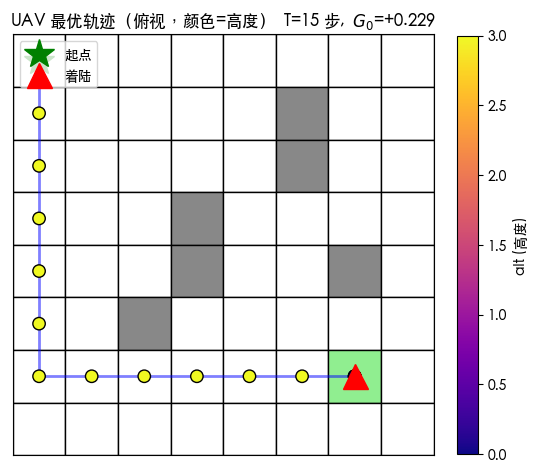

In [5]:
# 俯视图：忽略 alt 维度，按格子覆盖楼宇 alt=0 视图，绘制轨迹路径
fig, ax = plt.subplots(figsize=(6, 6))
mask0 = building_mask(env, 0)
for r in range(cfg.n_rows):
    for c in range(cfg.n_cols):
        y = cfg.n_rows - 1 - r
        if (r, c, 0) == cfg.target:
            color = '#90EE90'
        elif mask0[r, c]:
            color = '#888'
        else:
            color = 'white'
        ax.add_patch(Rectangle((c, y), 1, 1, facecolor=color, edgecolor='black'))

xs = [traj[0][0][1] + 0.5]
ys = [cfg.n_rows - 1 - traj[0][0][0] + 0.5]
alts = [traj[0][0][2]]
for _, _, _, sn in traj:
    xs.append(sn[1] + 0.5)
    ys.append(cfg.n_rows - 1 - sn[0] + 0.5)
    alts.append(sn[2])
ax.plot(xs, ys, 'b-', alpha=0.5, linewidth=2)
# 每个航点用高度上色
sc = ax.scatter(xs, ys, c=alts, cmap='plasma', s=80, edgecolors='black', zorder=3, vmin=0, vmax=cfg.n_alts-1)
ax.plot(xs[0], ys[0], 'g*', markersize=22, zorder=4, label='起点')
ax.plot(xs[-1], ys[-1], 'r^', markersize=18, zorder=4, label='着陆')

cbar = plt.colorbar(sc, ax=ax, fraction=0.045, label='alt (高度)')
ax.set_xlim(0, cfg.n_cols); ax.set_ylim(0, cfg.n_rows)
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'UAV 最优轨迹（俯视，颜色=高度）  T={len(traj)} 步,  $G_0$={G:+.3f}')
ax.legend(loc='upper left', fontsize=10)
plt.savefig('figures/uav_traj.png', dpi=120, bbox_inches='tight')
plt.show()


**观察**：颜色由亮（高空）逐渐变暗（地面）——VI 找出"先保持高空避开所有楼宇，最后阶段才连续 descend 着陆"的策略，电量利用接近最优。

## 6. 随机策略基线


随机策略 50 条轨迹：
  成功着陆率   = 0/50 (0%)
  平均长度     = 73.5
  平均折扣回报 = -1.1795

最优策略对比：长度 = 15, G_0 = +0.2288


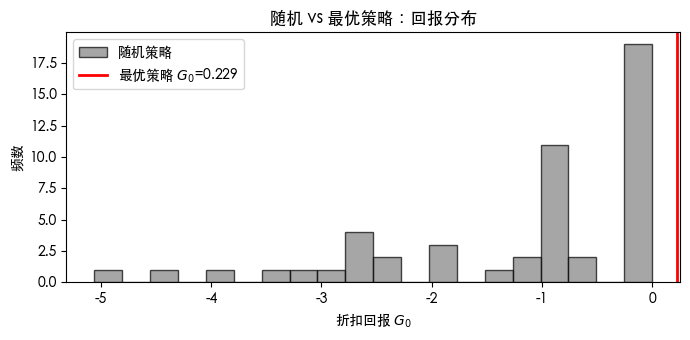

In [6]:
rng = np.random.default_rng(42)
n_trials = 50
returns_rand, lens_rand, success_rand = [], [], 0
for _ in range(n_trials):
    pi_rnd = random_policy(env, rng)
    traj_r = rollout(env, pi_rnd, max_steps=80)
    G_r = discounted_return(traj_r, cfg.gamma)
    returns_rand.append(G_r); lens_rand.append(len(traj_r))
    if traj_r[-1][3][:3] == cfg.target:  # 末端三元组 == target
        success_rand += 1

print(f'随机策略 {n_trials} 条轨迹：')
print(f'  成功着陆率   = {success_rand}/{n_trials} ({100*success_rand/n_trials:.0f}%)')
print(f'  平均长度     = {np.mean(lens_rand):.1f}')
print(f'  平均折扣回报 = {np.mean(returns_rand):+.4f}')
print(f'\n最优策略对比：长度 = {len(traj)}, G_0 = {G:+.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(returns_rand, bins=20, color='gray', alpha=0.7, edgecolor='black', label='随机策略')
ax.axvline(G, color='red', linewidth=2, label=f'最优策略 $G_0$={G:.3f}')
ax.set_xlabel('折扣回报 $G_0$'); ax.set_ylabel('频数'); ax.set_title('随机 vs 最优策略：回报分布')
ax.legend(); plt.tight_layout()
plt.savefig('figures/uav_returns_hist.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. 课堂诊断小结

| 维度 | GridWorld 5×5 | UAVGrid3D 8×8×4×16 | 倍数 |
|---|---|---|---|
| $\|\mathcal{S}\|$ | 25 | 4096 | ×164 |
| $\|\mathcal{A}\|$ | 5 | 7 | ×1.4 |
| 转移矩阵尺寸 | 25×25 = 625 | 4096×4096 ≈ 1.7×10⁷ | ×27 000 |
| VI 收敛步数 | ~30 (γ=0.9) | ~16 | 同量级 |
| VI 单轮 wall-clock | <1 ms | ~50–100 ms | ×50–100 |

**核心 takeaway**：
- 状态空间放大 100× 后，**算法本身没变**——VI 仍能在秒级收敛。表格法的边界在「能否枚举 $\mathcal{S}$」。
- 真实 UAV 任务会引入**连续高度、风场扰动、续航余量、多机协同**……每一项都让 $\|\mathcal{S}\|$ 指数膨胀。这就是 L8 函数逼近 / L9-L10 深度策略梯度的物理动机。
- 接下来 L4 的 notebook 会把 VI 在 GridWorld 和 UAVGrid3D 上做侧对侧对比，定量看「同样的算法 + 50× 状态 = 多少代价」。


## 8. 三维场景渲染：把"维度"画出来

§5 的俯视图能看位置和高度色码，但**楼宇的立体形状**与**轨迹绕楼/越顶**的空间关系仍要靠脑补。用 matplotlib `Axes3D.voxels` 把 8×8×4 离散网格画成体素 (voxel)，可以一眼看清：

- 不同高度的楼宇变矮（alt 越高，禁飞越少）
- 最优轨迹"先爬高 → 平飞穿越 → 末端俯冲"的物理直觉
- 起点（高空满电）→ 着陆点（地面 alt=0）的对角穿越


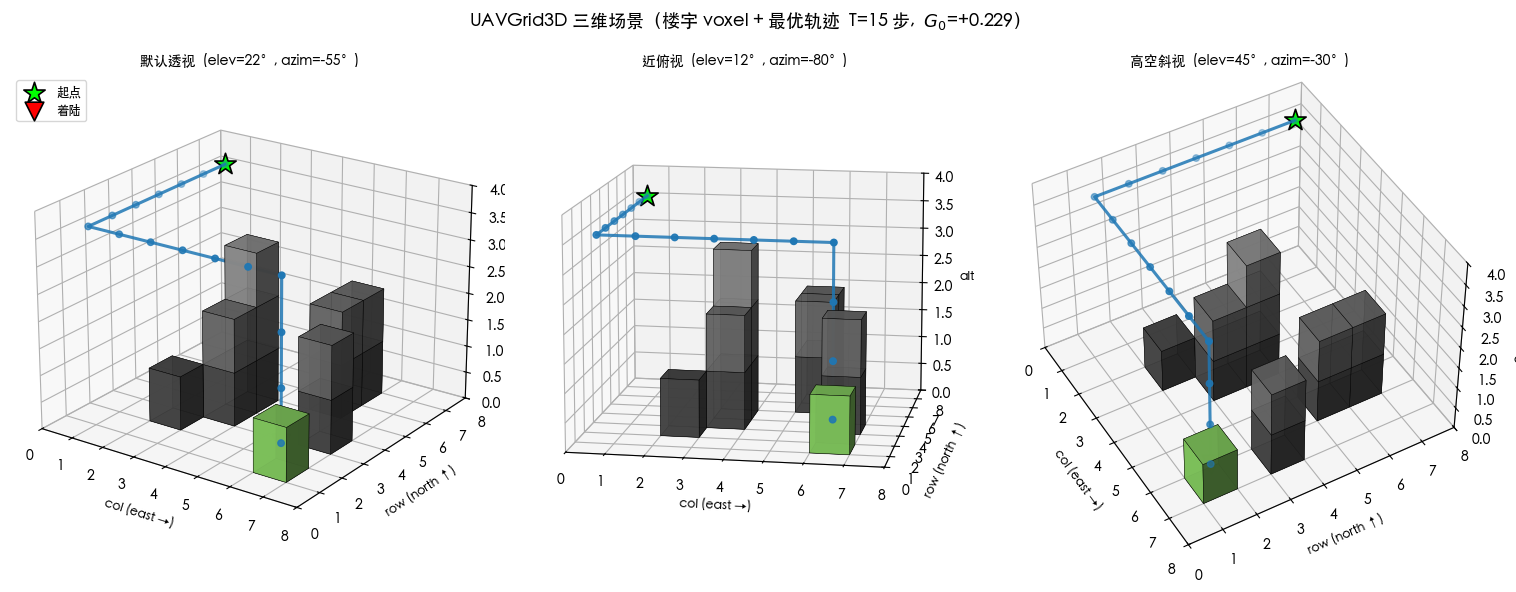

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  注册 3d projection

# 1. 构建体素填充矩阵：filled[x, y, z]
n_x = cfg.n_cols              # x ← col
n_y = cfg.n_rows              # y ← n_rows-1-row  (north-up)
n_z = cfg.n_alts              # z ← alt
filled = np.zeros((n_x, n_y, n_z), dtype=bool)
colors = np.empty(filled.shape, dtype=object)
for (r, c), h in cfg.building_height.items():
    x, y = c, n_y - 1 - r
    for alt in range(h):
        filled[x, y, alt] = True
        # 用渐变灰：低层深、高层浅，给视觉层次
        shade = 0.30 + 0.15 * alt
        colors[x, y, alt] = (shade, shade, shade, 0.85)

# 着陆点单独画一个绿色薄体素 (alt=0)
tr, tc, _ = cfg.target
tx, ty = tc, n_y - 1 - tr
filled[tx, ty, 0] = True
colors[tx, ty, 0] = (0.55, 0.85, 0.40, 0.95)

# 2. 把轨迹折线转到 3D 坐标（用 voxel 中心点）
pts = [traj[0][0]]
for _, _, _, sn in traj:
    pts.append(sn)
xs3 = [p[1] + 0.5 for p in pts]
ys3 = [n_y - 1 - p[0] + 0.5 for p in pts]
zs3 = [p[2] + 0.5 for p in pts]

# 3. 渲染：3 个不同视角并列
fig = plt.figure(figsize=(15, 5.5))
views = [(22, -55, '默认透视'), (12, -80, '近俯视'), (45, -30, '高空斜视')]

for idx, (elev, azim, title) in enumerate(views):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.voxels(filled, facecolors=colors, edgecolor='black', linewidth=0.3)
    # 轨迹
    ax.plot(xs3, ys3, zs3, color='#1f77b4', linewidth=2.2, alpha=0.85, zorder=10)
    ax.scatter(xs3, ys3, zs3, c='#1f77b4', s=22, zorder=11)
    # 起点 / 终点
    ax.scatter(xs3[0], ys3[0], zs3[0], marker='*', s=260, color='lime',
               edgecolors='black', linewidths=1.2, zorder=12, label='起点')
    ax.scatter(xs3[-1], ys3[-1], zs3[-1], marker='v', s=180, color='red',
               edgecolors='black', linewidths=1.2, zorder=12, label='着陆')
    # 坐标轴
    ax.set_xlim(0, n_x); ax.set_ylim(0, n_y); ax.set_zlim(0, n_z)
    ax.set_xlabel('col (east →)', fontsize=9)
    ax.set_ylabel('row (north ↑)', fontsize=9)
    ax.set_zlabel('alt', fontsize=9)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'{title}  (elev={elev}°, azim={azim}°)', fontsize=10)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

fig.suptitle(f'UAVGrid3D 三维场景（楼宇 voxel + 最优轨迹  T={len(traj)} 步,  $G_0$={G:+.3f}）',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/uav_scene_3d.png', dpi=130, bbox_inches='tight')
plt.show()


**设计说明**：

- **体素 (voxel)**：每个被楼宇占据的格子 `(row, col, alt)` 画成一个黑边小立方体；同一栋楼的多层用渐变灰呈现"楼层"
- **绿色薄体素**：着陆点（`target=(6,6,0)`），强调"必须降到地面才能着陆"
- **蓝色折线 + 圆点**：VI 最优轨迹，每个圆点是 voxel 中心
- **绿星 / 红三角**：起点 `(0,0, alt=3, bat=15)` 与终点
- **三视角**：默认透视 / 近俯视（接近俯视图但保留高度）/ 高空斜视——同一场景旋转视角看清空间关系

**与现有 2D 图的关系**：

- §2 的 4 层切片：**精确读取**每格状态（"alt=2 时 (3,3) 还在禁飞"）
- §5 的俯视轨迹：**路径与位置**清晰，高度用颜色色码
- §8 的三维场景：**空间结构** —— 楼宇形状、爬升/俯冲、绕楼策略一目了然

三张视角导出后可直接放进 PPT 的"UAV 应用线"那帧（L4/L6/L7），强化"维度爆炸"的视觉冲击。


## 9. 课后扩展（选做 · 难度递增）

下面 6 个扩展按难度从易到难。改动尽量集中在 `code/shared/uav_grid.py` + 本 notebook 末尾新加 cell，**不要破坏现有接口**——L4-L7 的算法 notebook 还会复用这套 env。

> 写完后欢迎在 `code/L01_MDP_foundations/figures/` 放对照图，或在 `miclDRL/` 章节里引用作为 PPT 案例。

### 9.1 ★ 旋转动画 GIF（半小时）
用 `matplotlib.animation.FuncAnimation` 让 §8 的三维场景绕 z 轴旋转一周（azim 从 -180° → +180°，30 帧），导出 `figures/uav_scene_spin.gif`。
**提示**：在每一帧里调用 `ax.view_init(elev=22, azim=k)`；保存用 `anim.save('figures/uav_scene_spin.gif', writer='pillow', fps=10)`。

### 9.2 ★★ 风场扰动（让 MDP 变随机）
当前 `step` 是确定性的。改造成：以概率 $\epsilon$ 把动作"被风吹偏"——例如想 `east`，有 $\epsilon/2$ 概率实际执行 `north`，$\epsilon/2$ 执行 `south`。
- 修改：`uav_grid.py` 中 `step` 的实现（保留旧的确定性接口，加 `stochastic=True/False` 开关）；transition_matrix 需要按概率写入多个非零项
- 跑 §4 VI 对比：随机性会让最优策略**更保守**（趋向飞中央而非贴边），$V^*$ 整体下降
- 思考：随机性变大后，VI 收敛步数变了吗？为什么？（参考 L4 收敛性证明）

### 9.3 ★★ 充电桩
在地图上加 1-2 个充电格 `(row, col, alt=0)`，飞过去就把 battery 重置满（或 +5）。
- 修改：`UAVConfig` 加 `charge_stations: tuple` 字段；`step` 中如果到达充电格，覆写 `bat_clip = cfg.n_battery - 1`
- 检验：把着陆点放远（比如 `target=(7,7,0)`）让"直飞到不了"，VI 应自动学会"绕路充电再飞过去"
- 教学价值：演示 reward shaping 之外的另一种**结构化先验**

### 9.4 ★★ 高度依赖的能耗模型
当前 `BATTERY_COST['ascend']=2` 是常数。改成"高空空气稀薄，ascend 在 alt=2→3 比 alt=0→1 更耗电"：
$$\text{cost}(\text{ascend at alt}=a) = 2 + a$$
- 修改：`step` 内联计算 `cost` 时考虑当前 alt
- 检验：VI 是否更倾向"先平飞再爬升"而不是"立刻拉高"

### 9.5 ★★★ 多目标巡航（任意先到一个）
把 `target` 从单点变成 set：`targets = [(6,6,0), (1,7,0)]`，到达**任意一个**就 $r=+1$ 终止。
- 修改：`UAVConfig.target` 改 tuple of tuples；`step` 检查 membership
- VI 应自动选**最近**的目标；如果两点对称，可能学到 stochastic optimal（多个 argmax）
- 进阶：把 reward 改成 `+1, +0.5`，看 VI 是否愿意为更高分多飞几步

### 9.6 ★★★★ 表格 Q-learning（不再需要 P 矩阵）
现在我们用 `value_iteration()` 解最优值——但 VI 要枚举 `transition_matrix`，这正是 L8 想摆脱的依赖。**直接在 UAV env 上跑表格 Q-learning**（L7 内容前置）：
- 在 `L07_TD_learning/` 新建 `uav_q_learning.ipynb`（如该目录还没有）
- 实现 $\epsilon$-greedy + $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma\max_{a'}Q(s',a') - Q(s,a)]$
- 训练 ~50000 个 episode，对比与 VI 最优值的差距曲线
- 你会发现：**4096 状态对表格 Q-learning 已经吃力**——每个状态平均要被访问几十次才稳定。这就是 L8 函数逼近的实证动机。

---

**提交方式**：完成任意 1-2 题就够了。把改动 commit 到 `code/shared/uav_grid.py` 或新增 notebook；图存 `code/L01_MDP_foundations/figures/`；写一句话总结发到课程群。
